In [1]:
import pandas as pd 
from matplotlib import pyplot as plt 
import seaborn as sbn
import numpy as np
import statsmodels.api as sm

In [2]:
mut = pd.read_csv('~/local/data/ccle/OmicsSomaticMutations.csv', sep=',')
mut.head()

/tmp/ipykernel_2818/343004040.py:1: DtypeWarning: Columns (28,52,56,58,59,61) have mixed types. Specify dtype option on import or set low_memory=False.
  mut = pd.read_csv('~/local/data/ccle/OmicsSomaticMutations.csv', sep=',')


,Unnamed: 0,SequencingID,ModelID,ModelConditionID,IsDefaultEntryForModel,IsDefaultEntryForMC,Chrom,Pos,Ref,Alt,...,GwasDisease,GwasPmID,GtexGene,ProveanPrediction,AMClass,AMPathogenicity,Rescue,RescueReason,Hotspot,EntrezGeneID
0,0,CDS-aN8PNg,ACH-000062,MC-000062-eiDD,Yes,Yes,chr1,818203,G,A,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,False,400728.0
1,1,CDS-1Zvqir,ACH-001949,MC-001949-eXWn,Yes,Yes,chr1,851926,G,A,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,False,643837.0
2,2,CDS-qjpRtt,ACH-002059,MC-002059-DNM1,Yes,Yes,chr1,918916,CTGA,C,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,False,100130417.0
3,3,CDS-bOBkBi,ACH-000402,MC-000402-iC8K,Yes,Yes,chr1,924510,GC,AA,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,False,148398.0
4,4,CDS-52aoJ0,ACH-000693,MC-000693-vUEr,Yes,Yes,chr1,924657,C,G,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,False,148398.0


In [3]:
mut = pd.read_csv('~/local/data/ccle/OmicsSomaticMutations.csv', sep=',')[['ModelID', 'HugoSymbol']].assign(is_mut=1).drop_duplicates()
mut = mut.pivot(index='ModelID', columns='HugoSymbol', values='is_mut').fillna(0).reset_index() 

/tmp/ipykernel_2818/400415363.py:1: DtypeWarning: Columns (28,52,56,58,59,61) have mixed types. Specify dtype option on import or set low_memory=False.
  mut = pd.read_csv('~/local/data/ccle/OmicsSomaticMutations.csv', sep=',')[['ModelID', 'HugoSymbol']].assign(is_mut=1).drop_duplicates()


In [4]:
cell_info = pd.read_csv('~/local/data/ccle_info.txt', sep=',')[['DepMap_ID', 'CCLE_Name', 'lineage', 'primary_disease', 'Subtype']].dropna()

mut = mut.merge(cell_info, left_on='ModelID', right_on='DepMap_ID', how='left')

mut = mut.set_index('DepMap_ID')

mut.head() 

,ModelID,A1BG,A1CF,A2M,A2ML1,A3GALT2,A4GALT,A4GNT,AAAS,AACS,...,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,CCLE_Name,lineage,primary_disease,Subtype
DepMap_ID,,,,,,,,,,,,,,,,,,,,,
ACH-000001,ACH-000001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,NIHOVCAR3_OVARY,ovary,Ovarian Cancer,"Adenocarcinoma, high grade serous"
ACH-000002,ACH-000002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,HL60_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,blood,Leukemia,"Acute Myelogenous Leukemia (AML), M3 (Promyelo..."
ACH-000004,ACH-000004,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,HEL_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,blood,Leukemia,"Acute Myelogenous Leukemia (AML), M6 (Erythrol..."
ACH-000005,ACH-000005,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,HEL9217_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,blood,Leukemia,"Acute Myelogenous Leukemia (AML), M6 (Erythrol..."
ACH-000006,ACH-000006,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,MONOMAC6_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,blood,Leukemia,"Acute Myelogenous Leukemia (AML), M5 (Eosinoph..."


In [5]:
# trametinib
target_drug = 'BRD-K12343256'

resp = pd.read_csv('~/local/data/ccle/sanger-dose-response.csv')
resp = resp[lambda x: x.BROAD_ID == target_drug]

df = mut.merge(resp, left_on='DepMap_ID', right_on='ARXSPAN_ID', how='left')
df = df.assign(zscore_auc=lambda x: (x.auc - x.auc.mean()) / x.auc.std())

In [ ]:
target_mirna = 'ET1' #'ETS1' #  'ETS1 (2113)' #'FOXO3 (2309)' 
target_drug = 'BRD-K12343256'

assert target_mirna in mut.columns


In [7]:
df__ = df[lambda x: x.CCLE_Name.str.contains('MCF7') \
    | x.CCLE_Name.str.contains('BT20') \
        | x.CCLE_Name.str.contains('MDAMB231') \
            | x.CCLE_Name.str.contains('T47D')][['DATASET', 'CCLE_Name', 'Z_SCORE_PUBLISHED', 'auc', target_mirna]]

df__.style.hide()

DATASET,CCLE_Name,Z_SCORE_PUBLISHED,auc,ETV1
GDSC1,MCF7_BREAST,1.311511,0.976778,0.000000
GDSC2,MCF7_BREAST,1.761750,nan,0.000000
GDSC1,T47D_BREAST,1.176727,0.937388,0.000000
GDSC2,T47D_BREAST,1.530974,0.933038,0.000000
GDSC1,BT20_BREAST,0.180402,0.755402,0.000000
GDSC2,BT20_BREAST,0.194446,0.854801,0.000000
GDSC1,MDAMB231_BREAST,-0.586737,0.603333,0.000000
GDSC2,MDAMB231_BREAST,-0.472021,0.745774,0.000000


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0.0 vs. 1.0: Mann-Whitney-Wilcoxon test two-sided, P_val:1.935e-01 U_stat=8.000e+00


/tmp/ipykernel_2818/3866152153.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


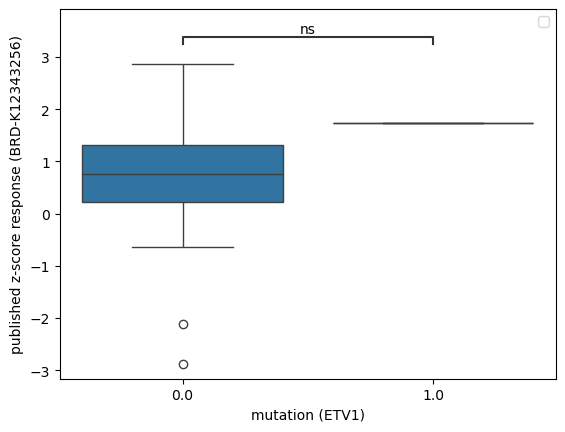

In [8]:
target_resp = 'Z_SCORE_PUBLISHED' 
target_expr = target_mirna
target_dataset = 'GDSC1'

df_breast = df[lambda x: (x.primary_disease == 'Breast Cancer') & (x.DATASET == target_dataset)][[target_expr, target_resp]].dropna()

from statannotations.Annotator import Annotator

plt.figure() 
sbn.boxplot(x=target_expr, y=target_resp, data=df[lambda x: x.primary_disease == 'Breast Cancer']) 
ax = plt.gca()
pairs = [(0,1)]
annotator = Annotator(ax, pairs, data=df[lambda x: x.primary_disease == 'Breast Cancer'], x=target_expr, y=target_resp)
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
annotator.apply_and_annotate()
plt.legend()
plt.xlabel(f'mutation ({target_mirna})')
plt.ylabel(f'published z-score response ({target_drug})')
plt.show() 

# All correlations

In [9]:
corrs = df[lambda x: (x.primary_disease == 'Breast Cancer') & (x.DATASET == target_dataset)][df.columns[1:-25].tolist() + ['Z_SCORE_PUBLISHED']].corr(method='spearman')[['Z_SCORE_PUBLISHED']]

In [21]:
corrs.dropna().sort_values(by='Z_SCORE_PUBLISHED', ascending=False).head(25)#[lambda x: x.index.str.contains('ETV1')]

,Z_SCORE_PUBLISHED
Z_SCORE_PUBLISHED,1.000000
RPS6KC1,0.420883
WHRN,0.411577
ZAN,0.408349
FLNB,0.404718
TET3,0.404718
APEX2,0.404718
MUC17,0.399230
CDC27,0.397858
MYORG,0.397460


In [22]:
corrs.dropna().sort_values(by='Z_SCORE_PUBLISHED', ascending=False).tail(25)#[lambda x: x.index.str.contains('ETV1')]

,Z_SCORE_PUBLISHED
NEB,-0.295163
QRFPR,-0.298909
CASTOR1,-0.301823
ST14,-0.301823
UNC79,-0.302015
EGR1,-0.306643
LORICRIN,-0.307212
EIF3M,-0.307212
MN1,-0.315543
GGA3,-0.322402
